In [1]:
import pandas as pd
df = pd.read_csv("https://data.illinois.gov/api/views/64q4-57u5/rows.csv?accessType=DOWNLOAD")
df.head()

,File Number,Date Reported,Year Reported,Month Reported,Housing Block,Street Name,Date Notice Mailed or Given,Type of Complaint,Disposition,File Close Date,Method Submitted,Submitted Online?,Total Fees,Mapped Location,georeference
0,25-003482,10/29/2025 12:00:00 AM,2025,10,2200 Block,South Lynn Street,NaN,NaN,Addressed under different complaint file,10/29/2025 12:00:00 AM,Internet,True,0.0,"2200 South Lynn Street Urbana, IL",POINT (-88.19693 40.08975)
1,25-003463,10/28/2025 12:00:00 AM,2025,10,1000 Block,South Lanore Drive,10/28/2025 12:00:00 AM,Weeds/Grass,NaN,NaN,Phone,False,0.0,"1000 South Lanore Drive Urbana, IL",POINT (-88.1866 40.10409)
2,25-003464,10/28/2025 12:00:00 AM,2025,10,700 Block,East Illinois Street,10/28/2025 12:00:00 AM,Weeds/Grass,NaN,NaN,Phone,False,0.0,"700 East Illinois Street Urbana, IL",POINT (-88.20007 40.10936)
3,25-003465,10/28/2025 12:00:00 AM,2025,10,400 Block,East California Avenue,10/28/2025 12:00:00 AM,Weeds/Grass,NaN,NaN,Phone,False,0.0,"400 East California Avenue Urbana, IL",POINT (-88.20348 40.10852)
4,25-003466,10/28/2025 12:00:00 AM,2025,10,500 Block,East Washington Street,10/28/2025 12:00:00 AM,Weeds/Grass,NaN,NaN,Phone,False,0.0,"500 East Washington Street Urbana, IL",POINT (-88.20225 40.10566)


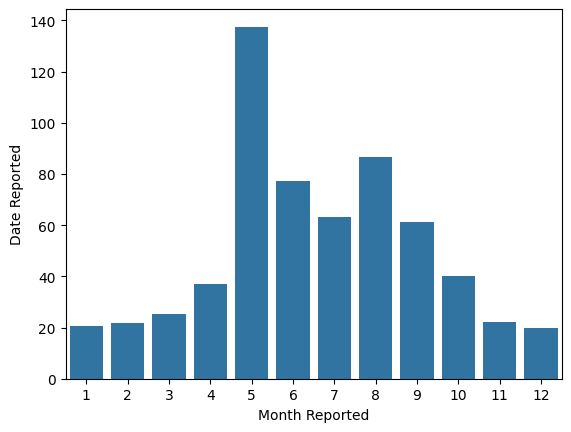

In [2]:
import seaborn as sns
import altair as alt
import matplotlib.pyplot as plt
month_trends = df.groupby('Month Reported')['Date Reported'].agg('count')
median = df.groupby(['Year Reported', 'Month Reported'])['Date Reported'].agg('count').reset_index()
mean_reports_per_month = median.groupby('Month Reported').agg('mean').reset_index()
sns.barplot(data = mean_reports_per_month, x='Month Reported', y = 'Date Reported')
plt.show()

In [22]:
import altair as alt

year = alt.param(name='year', bind=alt.binding_select(options=sorted(df['Year Reported'].unique())), value=2023)
month = alt.param(name='month', bind=alt.binding_range(min=1, max=12, step=1), value=4)

chart = (
    alt.Chart(df).add_params(year, month).transform_filter("datum['Year Reported'] == year").
    transform_filter("datum['Month Reported'] == month").
    mark_bar().
    encode(x=alt.X('Type of Complaint:N', sort='-y'), y='count()', color='Type of Complaint:N').
    properties(width=400, height=250)
)

chart
chart.save('complaints.json')

In [5]:
df['Type of Complaint'].value_counts()

Type of Complaint
Weeds/Grass           8345
Municipal Waste       5102
Unknown                500
Zoning                  60
Snow Removal            35
Tenant Complaint         8
Neighborhood             2
Undetermined Noise       1
Name: count, dtype: int64

In [41]:
subset = df[(df['Type of Complaint'] == 'Weeds/Grass') & (df['Total Fees'] < 15000)].copy()
subset["index"] = range(len(subset)) 

chart = alt.Chart(subset).mark_point(size=30, opacity=0.6).encode(
    x=alt.X('index:Q', title='Index'),
    y=alt.Y('Total Fees:Q', title='Total Fees'),
    tooltip=['index', 'Total Fees']
).properties(title='Weeds/Grass Complaint Fees')
chart


alt.Chart(...)

In [42]:
chart.save('weeds.json')

In [27]:
#sns.scatterplot(df[(df['Type of Complaint'] == 'Weeds/Grass') & (df['Total Fees'] < 15000)]['Total Fees'])

In [43]:
subset = df[df['Type of Complaint'] == 'Municipal Waste'].copy()
subset["index"] = range(len(subset)) 

chart = alt.Chart(subset).mark_point(size=30, opacity=0.8).encode(
    x=alt.X('index:Q', title='Index'),
    y=alt.Y('Total Fees:Q', title='Total Fees'),
    tooltip=['index', 'Total Fees']
).properties(title='Municipal Waste Complaint Fees')
chart


alt.Chart(...)

In [44]:
chart.save('waste.json')

<Axes: ylabel='Total Fees'>

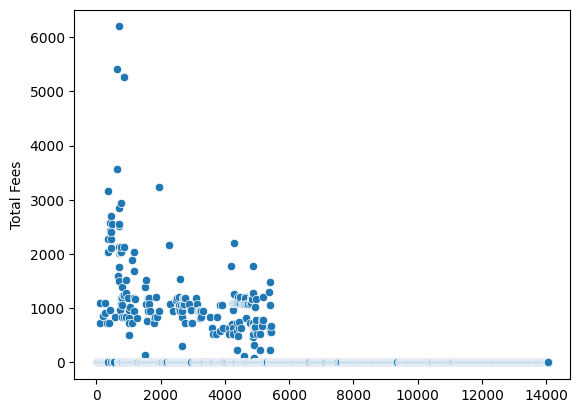

In [29]:
sns.scatterplot(df[df['Type of Complaint'] == 'Municipal Waste']['Total Fees'])